In [1]:
import pandas as pd

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

In [33]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
df=pd.read_csv("/content/Resume.csv")

In [3]:
df

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR
...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


In [8]:
df=df.drop("ID",axis=1)

In [9]:
df.shape

(2484, 2)

In [10]:
df

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR
...,...,...
2479,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION
2480,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION
2481,GEEK SQUAD AGENT Professional...,AVIATION
2482,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION


In [11]:
df.isnull().sum()

,0
Resume_str,0
Category,0


In [12]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2479,False
2480,False
2481,False
2482,False


In [15]:
df.drop_duplicates().sum()

,0
Resume_str,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
Category,HRHRHRHRHRHRHRHRHRHRHRHRHRHRHRHRHRHRHRHRHRHRHR...


<Axes: title={'center': 'Category'}, xlabel='Category'>

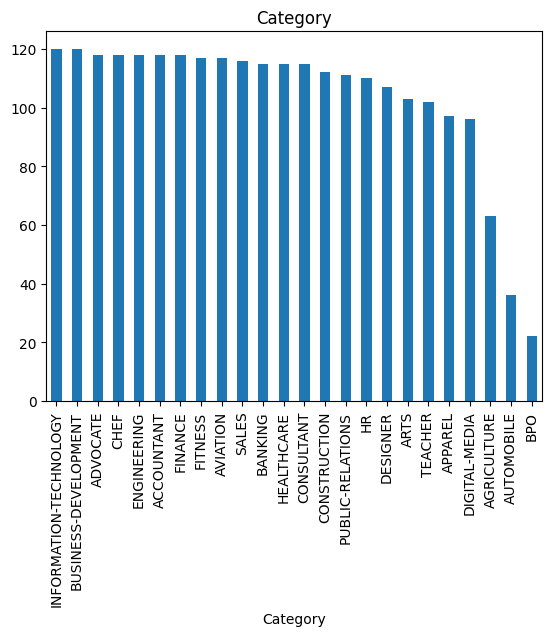

In [16]:
df["Category"].value_counts().plot(kind="bar",title="Category")

In [18]:
df.shape

(2484, 2)

## Text PreProcessing

** Lower Casing **

In [21]:
df["Resume_str"]=df["Resume_str"].str.lower()

In [22]:
df["Resume_str"]

,Resume_str
0,hr administrator/marketing associate\...
1,"hr specialist, us hr operations ..."
2,hr director summary over 2...
3,hr specialist summary dedica...
4,hr manager skill highlights ...
...,...
2479,rank: sgt/e-5 non- commissioned offic...
2480,"government relations, communications ..."
2481,geek squad agent professional...
2482,program director / office manager ...


*Punctuation Removing*

In [23]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [24]:
df["Resume_str"]=df["Resume_str"].apply(remove_punctuation)

*  Removing Extra Spaces *

In [26]:
def remove_extra_spaces(text):
    return " ".join(text.split())

In [27]:
df["Resume_str"]=df["Resume_str"].apply(remove_extra_spaces)

In [93]:
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [95]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [97]:
df['Resume_str'] = df['Resume_str'].apply(clean_text)

*StopWords Removing*

In [98]:
stop_words = set(stopwords.words('english'))

def remove_stopword(text):
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

In [99]:
df["Resume_str"]=df["Resume_str"].apply(remove_stopword)

In [101]:
category_counts = df['Category'].value_counts()

valid_categories = category_counts[category_counts >= 10].index

df = df[df['Category'].isin(valid_categories)]

In [102]:
df.shape

(2484, 2)

In [123]:
X=df["Resume_str"]
y=df["Category"]

In [104]:
X.shape

(2484,)

In [47]:
X

,Resume_str
0,hr administratormarketing associate hr adminis...
1,hr specialist us hr operations summary versati...
2,hr director summary 20 years experience recrui...
3,hr specialist summary dedicated driven dynamic...
4,hr manager skill highlights hr skills hr depar...
...,...
2479,rank sgte5 non commissioned officer charge bri...
2480,government relations communications organizati...
2481,geek squad agent professional profile support ...
2482,program director office manager summary highly...


In [76]:
y.shape

(2484,)

##*TFIDF*##

In [125]:
tf=TfidfVectorizer()
X=tf.fit_transform(df["Resume_str"])

In [106]:
le=LabelEncoder()
y=le.fit_transform(y)

In [81]:
y.shape

(2484,)

In [107]:
X_train,X_test,y_train,y_test=train=train_test_split(X,y,test_size=0.2,random_state=42)

In [108]:
svm=SVC()
svm.fit(X_train,y_train)
y_pred=svm.predict(X_test)


In [109]:
print("accuracy_score",accuracy_score(y_test,y_pred))

accuracy_score 0.5835010060362174


In [110]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  4  0  1  0  0  0  0  0]
 [ 0 17  0  0  1  0  0  0  0  0  0  0  2  0  0  0  0  0  9  0  0  0  1  0]
 [ 1  0  1  0  0  0  0  0  0  1  0  0  1  0  0  1  0  0  0  0  0  0  1  2]
 [ 0  1  0  7  2  0  0  0  0  0  0  0  1  1  0  2  0  0  0  0  0  0  6  0]
 [ 0  0  0  1  3  0  0  0  0  0  1  0  2  1  0  0  0  0  1  1  2  0  1  5]
 [ 0  4  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  1  0  0  0  0  3  0  0  0]
 [ 1  0  0  0  1  0  0 16  0  0  0  0  4  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  1  0 16  0  0  3  0  0  0  0  0  3  0  0  1  2  0]
 [ 0  0  0  1  1  0  2  0  0  0 15  0  1  0  0  0  0  0  1  0  0  0  2  1]
 [ 0  0  0  2  3  0  4  0  0  0  0 21  2  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  2  0  0  0  1  6  0  1  1  0  0  3  1  4  1  0  0]
 [ 0  0  0  1  0  0  0  0

In [111]:
print("classification_report",classification_report(y_test,y_pred))

classification_report               precision    recall  f1-score   support

           0       0.73      0.83      0.77        29
           1       0.49      0.57      0.52        30
           2       1.00      0.12      0.22         8
           3       0.47      0.35      0.40        20
           4       0.13      0.17      0.15        18
           5       0.00      0.00      0.00         6
           6       0.63      0.81      0.71        21
           7       0.76      0.70      0.73        23
           8       0.00      0.00      0.00         2
           9       0.76      0.59      0.67        27
          10       0.88      0.62      0.73        24
          11       0.91      0.62      0.74        34
          12       0.16      0.30      0.21        20
          13       0.79      0.79      0.79        19
          14       0.89      0.64      0.74        25
          15       0.56      0.67      0.61        21
          16       0.54      0.37      0.44        19
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [112]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [113]:
y_p = model.predict(X_test)

In [114]:
accuracy = accuracy_score(y_test, y_p)

print("Accuracy:", accuracy)

Accuracy: 0.5271629778672032


In [115]:
print(classification_report(y_test, y_p))

              precision    recall  f1-score   support

           0       0.76      0.86      0.81        29
           1       0.64      0.30      0.41        30
           2       0.00      0.00      0.00         8
           3       0.80      0.20      0.32        20
           4       0.00      0.00      0.00        18
           5       0.00      0.00      0.00         6
           6       0.63      0.81      0.71        21
           7       0.85      0.48      0.61        23
           8       0.00      0.00      0.00         2
           9       0.42      0.63      0.51        27
          10       0.81      0.71      0.76        24
          11       0.95      0.53      0.68        34
          12       0.50      0.05      0.09        20
          13       0.82      0.74      0.78        19
          14       1.00      0.16      0.28        25
          15       0.50      0.57      0.53        21
          16       0.34      0.58      0.43        19
          17       0.44    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [116]:
cm = confusion_matrix(y_test, y_p)

print(cm)

[[25  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  0  1  0  0  0  0  0]
 [ 0  9  0  0  0  0  0  0  0  1  0  0  0  0  0  0  1  1 11  4  1  0  1  1]
 [ 1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  1  0  1  0  0  1  1  0  2]
 [ 0  0  0  4  0  0  0  1  0  1  0  0  0  1  0  3  2  1  0  1  0  1  5  0]
 [ 0  0  0  0  0  0  0  0  0  1  1  0  0  1  0  0  1  1  1  2  3  0  2  5]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  1  3  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0]
 [ 1  0  0  0  0  0  0 11  0  1  0  0  0  0  0  0  6  1  0  0  3  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  1  0 17  0  0  1  0  0  0  1  0  3  2  0  1  1  0]
 [ 0  0  0  0  0  0  1  0  0  1 17  0  0  0  0  0  0  1  2  0  0  1  1  0]
 [ 0  0  0  0  1  0  3  0  0  1  0 18  0  0  0  3  1  1  3  1  0  0  2  0]
 [ 0  0  0  0  0  0  0  0  0  2  0  1  1  0  0  1  1  0  3  1  8  2  0  0]
 [ 0  0  0  0  0  0  0  0

##SVM Testing

In [149]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# assume tf and model already trained

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)


# -------------------------
# INPUT RESUME TEXT
# -------------------------
resume_text = """
CUSTOMER SERVICES
Summary
Professional in Economics with 7+ years of experience in the financial sector, as administrative assistant, manager, analyst and customer services.
Optimizing work methods through the planning and execution of daily activities that correspond to my position. Â I have the ability to work in a fast
paced environment, successful in maintaining multiple tasks, able to work well individually or with a team, dedicated and focused to achieve the
objectives.
Highlights
Leadership
Strategic Planner
Customer relationship
Management Support
Financial Trader
Â Analysis
Accomplishments
Improved department efficiency 40% through implementation of strategic workflow and process improvements.
Maintained accurate accounts including cash, inventory, prepaid, fixed assets, accounts payable, accrued expenses and line of credit transactions.
â€‹
Â Created new operational planning strategy to drive business development
â€‹
Researched, calmed and rapidly resolved client conflicts to mantain customer relationship.
Experience
07/2016 to 11/2016
Customer Services Company Name ï¼ City , State
Support english and spanish incoming call flow
Provide information to new and existing customers to support their needs and finding a solutions to keep customers satisfied and retain
business.
Navigate computer systems to properly conduct the objective of the campaign and locate customer data or other electronic information,
records each call by accurately documenting status and comments in the platform.
06/2013 to 05/2015
Manager - BPO Analyst Company Name ï¼ City
Lead Team of 15 professionalsÂ
Analysis coordinator and risk management for Citibank International.
Record national and international ACH transactions to Â reduce risk of fraud and comply the policies and government regulations. Â
Create monthly reports to maintain the business control.
Define strategy and bussines plan to control the volume transactionsÂ
Train and suppot Â risk personnel during new system implementations ans upgrades
10/2008 to 05/2013
Financial Assistant - Trader Company Name ï¼ City
Support the financial investment area in buying and selling financial assets.
Advise the customer Â with their investments to higer returns
Find solutions to customer's necessities through e-mail and phone calls.
Organize electronic files and maintain paper files updates
Â Verify details of transactions, including funds received and total account balances.
Â Deposite dividend Payments, settle invoices, administer the petty cash to keep the office up to day
provide financial reports and Â office supplies
Open ans assign new Client Accounts.
Keep confidential information.
Education
2014
Bachelor of Science : Economics City Colombia Economics
YENI MALDONADO
Languages
Spanish - English - Portuguese
Skills
Attention to detail, Billing, Customer Services, data Analysis, Documentation, e-mail, English, organize files, financial, financial reports, investments,
Leadership, meetings,Risk Management, selling, Spanish, Strategic Planning, phone, web page
    """

# -------------------------
# PIPELINE
# -------------------------
cleaned = clean_text(resume_text)

vector = tf.transform([cleaned])

prediction = svm.predict(vector)

print("Predicted Category:", prediction[0])

Predicted Category: 7


In [148]:
predicted_category_name = le.inverse_transform(prediction)
print(f"The predicted category name is: {predicted_category_name[0]}")

The predicted category name is: BANKING


##Naive Bayes Testing

In [151]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# assume tf and model already trained

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)


# -------------------------
# INPUT RESUME TEXT
# -------------------------
resume_text = """
CUSTOMER SERVICES
Summary
Professional in Economics with 7+ years of experience in the financial sector, as administrative assistant, manager, analyst and customer services.
Optimizing work methods through the planning and execution of daily activities that correspond to my position. Â I have the ability to work in a fast
paced environment, successful in maintaining multiple tasks, able to work well individually or with a team, dedicated and focused to achieve the
objectives.
Highlights
Leadership
Strategic Planner
Customer relationship
Management Support
Financial Trader
Â Analysis
Accomplishments
Improved department efficiency 40% through implementation of strategic workflow and process improvements.
Maintained accurate accounts including cash, inventory, prepaid, fixed assets, accounts payable, accrued expenses and line of credit transactions.
â€‹
Â Created new operational planning strategy to drive business development
â€‹
Researched, calmed and rapidly resolved client conflicts to mantain customer relationship.
Experience
07/2016 to 11/2016
Customer Services Company Name ï¼ City , State
Support english and spanish incoming call flow
Provide information to new and existing customers to support their needs and finding a solutions to keep customers satisfied and retain
business.
Navigate computer systems to properly conduct the objective of the campaign and locate customer data or other electronic information,
records each call by accurately documenting status and comments in the platform.
06/2013 to 05/2015
Manager - BPO Analyst Company Name ï¼ City
Lead Team of 15 professionalsÂ
Analysis coordinator and risk management for Citibank International.
Record national and international ACH transactions to Â reduce risk of fraud and comply the policies and government regulations. Â
Create monthly reports to maintain the business control.
Define strategy and bussines plan to control the volume transactionsÂ
Train and suppot Â risk personnel during new system implementations ans upgrades
10/2008 to 05/2013
Financial Assistant - Trader Company Name ï¼ City
Support the financial investment area in buying and selling financial assets.
Advise the customer Â with their investments to higer returns
Find solutions to customer's necessities through e-mail and phone calls.
Organize electronic files and maintain paper files updates
Â Verify details of transactions, including funds received and total account balances.
Â Deposite dividend Payments, settle invoices, administer the petty cash to keep the office up to day
provide financial reports and Â office supplies
Open ans assign new Client Accounts.
Keep confidential information.
Education
2014
Bachelor of Science : Economics City Colombia Economics
YENI MALDONADO
Languages
Spanish - English - Portuguese
Skills
Attention to detail, Billing, Customer Services, data Analysis, Documentation, e-mail, English, organize files, financial, financial reports, investments,
Leadership, meetings,Risk Management, selling, Spanish, Strategic Planning, phone, web page
    """

# -------------------------
# PIPELINE
# -------------------------
cleaned = clean_text(resume_text)

vector = tf.transform([cleaned])

prediction = model.predict(vector)

print("Predicted Category:", prediction[0])

predicted_category_name = le.inverse_transform(prediction)
print(f"The predicted category name is: {predicted_category_name[0]}")

Predicted Category: 16
The predicted category name is: FINANCE
